# Trabajo Practico Integrador — Entrega 3
## Ciencia de Datos 2026 | UTN FRC | 5K4 | Grupo 15

---

### Descripcion

Valida la **Hipotesis H1** comparando dos algoritmos de regresion y tres de clasificacion por arboles.

> **H1:** *"Existe una correlacion positiva y cuantificable entre la frecuencia cardiaca media del sujeto y el nivel de intensidad de la actividad fisica clasificada (baja, moderada y vigorosa)."*

**Division de datos:** sujetos 102, 106, 108 para prueba (~35%). Resto (incluido sujeto 109) para entrenamiento.

---

| Rol | Nombre | Legajo |
|-----|--------|--------|
| Product Owner | Franco Recalde | 94661 |
| Scrum Master | Emilio Sadir | 96622 |
| dev | Rodriguez, Joaquin Ignacio | 85406 |
| dev | Noto, Claudia Carina | 95215 |
| dev | Monteros, Leandro Ignacio | 90258 |
| dev | Ferraro, Ayelen | 99149 |
| dev | Chiaro, Tiziano | 90043 |
| dev | Bailey, Julian Eduardo | 96032 |

---
# Seccion 0 — Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               RandomForestRegressor)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, r2_score,
    mean_squared_error, mean_absolute_error
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print('Librerias cargadas.')

Librerias cargadas.


In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/TP_CD')
else:
    BASE_PATH = Path('..').resolve()

DATA_PATH    = BASE_PATH / 'data' / 'processed' / 'pamap2_limpio.csv'
FIGURES_PATH = BASE_PATH / 'reports' / 'entrega_3' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')

Entorno: Local


In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas | Nulos: {df.isnull().sum().sum()}')
total = len(df)
filas_x_sujeto = df.groupby('sujeto_id').size().rename('filas')
display(pd.concat([filas_x_sujeto, (filas_x_sujeto/total*100).round(1).rename('pct%')], axis=1))

Shape: 109,812 filas x 43 columnas | Nulos: 0


,filas,pct%
sujeto_id,,
101,14057,12.8000
102,13039,11.9000
103,10005,9.1000
104,13967,12.7000
105,15586,14.2000
106,15009,13.7000
107,17346,15.8000
108,10390,9.5000
109,413,0.4000


### Paso 0.3 — Constantes, feature engineering y funciones auxiliares

In [5]:
# --- Nombres de actividades en espanol ---
ACTIVIDAD_MAP = {
    1: 'acostado',        2: 'sentado',          3: 'de pie',
    4: 'caminata',        5: 'corriendo',         6: 'ciclismo',
    7: 'marcha nordica',  12: 'subir escaleras', 13: 'bajar escaleras',
    16: 'aspirar',        17: 'planchar',          24: 'saltar soga'
}

# Ciclismo = vigoroso (alta demanda cardiovascular)
INTENSIDAD_MAP = {
    1: 0, 2: 0, 3: 0,       # baja:     acostado, sentado, de pie
    4: 1, 16: 1, 17: 1,     # moderada: caminata, aspirar, planchar
    5: 2, 6: 2, 7: 2,       # vigorosa: corriendo, ciclismo, marcha nordica
    12: 2, 13: 2, 24: 2,    # vigorosa: subir/bajar escaleras, saltar soga
}
INTENSIDAD_NOMBRES = {0: 'baja', 1: 'moderada', 2: 'vigorosa'}
INTENSIDAD_COLORES = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
INTENSIDAD_ORDEN   = ['baja', 'moderada', 'vigorosa']

# --- Feature engineering: nivel_intensidad ---
df['nivel_intensidad'] = df['actividad_id'].map(INTENSIDAD_MAP)

# --- Magnitudes de aceleracion y giro (invariantes a la orientacion del sensor) ---
# sqrt(x^2 + y^2 + z^2) elimina sesgo inter-sujeto por diferencias en colocacion del sensor.
# Una persona puede llevar el sensor rotado respecto a otra; la magnitud no cambia.
for parte in ['mano', 'pecho', 'tobillo']:
    for sensor in ['acel1', 'acel2']:
        cols = [f'{parte}_{sensor}_{ax}' for ax in ['x', 'y', 'z']]
        if all(c in df.columns for c in cols):
            df[f'{parte}_{sensor}_mag'] = np.sqrt((df[cols] ** 2).sum(axis=1))
    cols_g = [f'{parte}_giro_{ax}' for ax in ['x', 'y', 'z']]
    if all(c in df.columns for c in cols_g):
        df[f'{parte}_giro_mag'] = np.sqrt((df[cols_g] ** 2).sum(axis=1))

SENSOR_COLS = [c for c in df.columns
               if c not in ['tiempo', 'actividad_id', 'sujeto_id', 'nivel_intensidad']]
mag_cols = [c for c in SENSOR_COLS if c.endswith('_mag')]

print(f'SENSOR_COLS total: {len(SENSOR_COLS)} features')
print(f'  Magnitudes nuevas ({len(mag_cols)}): {mag_cols}')
print()
print('Distribucion nivel_intensidad:')
for k in [0, 1, 2]:
    n    = (df['nivel_intensidad'] == k).sum()
    acts = [ACTIVIDAD_MAP[a] for a, v in INTENSIDAD_MAP.items() if v == k]
    print(f'  {INTENSIDAD_NOMBRES[k]:10s} ({k}): {n:,} filas ({n/len(df)*100:.1f}%)  <- {acts}')


def plot_cm(y_true, y_pred, labels, label_names, title, filename=None, figsize=(12, 10)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_xlabel('Predicho', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    if filename:
        plt.savefig(FIGURES_PATH / filename, dpi=100, bbox_inches='tight')
    plt.show()

SENSOR_COLS total: 49 features
  Magnitudes nuevas (9): ['mano_acel1_mag', 'mano_acel2_mag', 'mano_giro_mag', 'pecho_acel1_mag', 'pecho_acel2_mag', 'pecho_giro_mag', 'tobillo_acel1_mag', 'tobillo_acel2_mag', 'tobillo_giro_mag']

Distribucion nivel_intensidad:
  baja       (0): 27,527 filas (25.1%)  <- ['acostado', 'sentado', 'de pie']
  moderada   (1): 38,902 filas (35.4%)  <- ['caminata', 'aspirar', 'planchar']
  vigorosa   (2): 43,383 filas (39.5%)  <- ['corriendo', 'ciclismo', 'marcha nordica', 'subir escaleras', 'bajar escaleras', 'saltar soga']


---
# Seccion 1 — Exploracion y Division por Sujetos

**Mapeo de intensidad:**

| Nivel | Cod | Actividades |
|-------|-----|-------------|
| Baja | 0 | acostado, sentado, de pie |
| Moderada | 1 | caminata, aspirar, planchar |
| Vigorosa | 2 | corriendo, **ciclismo**, marcha nordica, subir/bajar escaleras, saltar soga |

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12620\1554710009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',


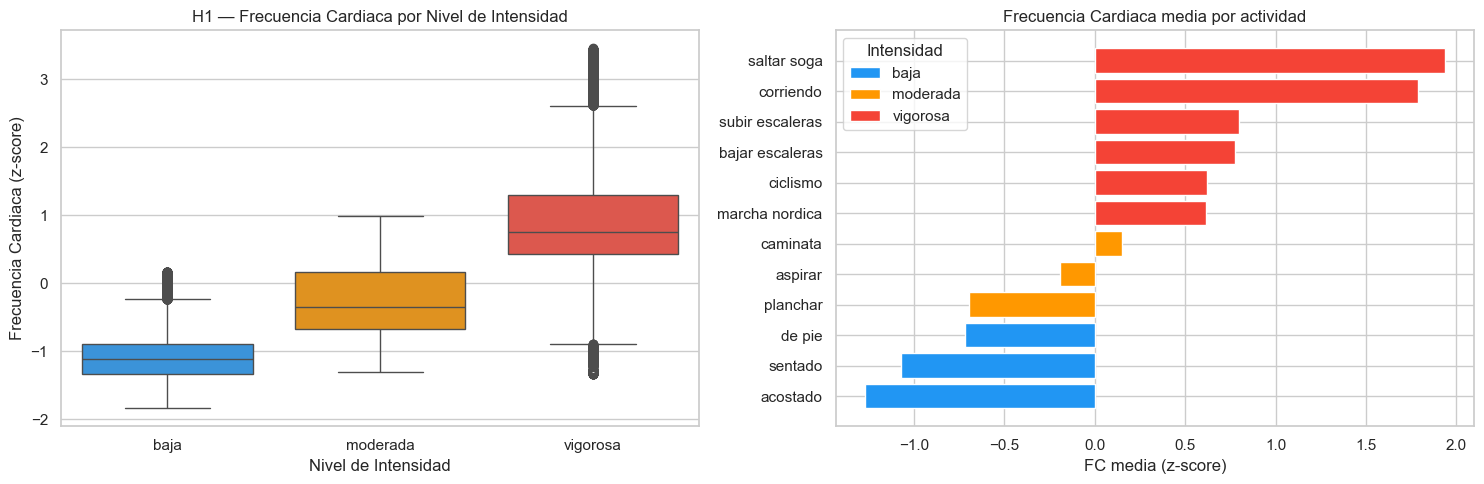

,count,mean,std,min,25%,50%,75%,max
nivel_intensidad,,,,,,,,
baja,27527.0000,-1.0724,0.3948,-1.8397,-1.3289,-1.1130,-0.8911,0.1669
moderada,38902.0000,-0.2578,0.4973,-1.3107,-0.6722,-0.3438,0.1669,0.9795
vigorosa,43383.0000,0.9116,0.7683,-1.3289,0.4223,0.7507,1.2979,3.4505


In [6]:
df_plot = df.copy()
df_plot['nivel_nombre'] = df_plot['nivel_intensidad'].map(INTENSIDAD_NOMBRES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_plot, x='nivel_nombre', y='frecuencia_cardiaca',
            order=INTENSIDAD_ORDEN,
            palette=[INTENSIDAD_COLORES[k] for k in [0, 1, 2]], ax=axes[0])
axes[0].set_title('H1 — Frecuencia Cardiaca por Nivel de Intensidad', fontsize=12)
axes[0].set_xlabel('Nivel de Intensidad')
axes[0].set_ylabel('Frecuencia Cardiaca (z-score)')

fc_media   = df.groupby('actividad_id')['frecuencia_cardiaca'].mean().sort_values()
bar_colors = [INTENSIDAD_COLORES[INTENSIDAD_MAP[a]] for a in fc_media.index]
act_names  = [ACTIVIDAD_MAP.get(a, str(a)) for a in fc_media.index]
axes[1].barh(act_names, fc_media.values, color=bar_colors)
axes[1].set_title('Frecuencia Cardiaca media por actividad', fontsize=12)
axes[1].set_xlabel('FC media (z-score)')
axes[1].legend(handles=[mpatches.Patch(facecolor=INTENSIDAD_COLORES[k],
               label=INTENSIDAD_NOMBRES[k]) for k in [0, 1, 2]], title='Intensidad')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'h1_boxplot_intensidad.png', dpi=100, bbox_inches='tight')
plt.show()
display(df.groupby('nivel_intensidad')['frecuencia_cardiaca'].describe().rename(index=INTENSIDAD_NOMBRES))

### 1.2 — Division por Sujetos

Los **sujetos 102, 106, 108** conforman el conjunto de prueba (~35.0%, 38.438 filas).
El resto —incluido el sujeto 109— forma el conjunto de entrenamiento.

> **Por que no split aleatorio?** Si filas del mismo sujeto estan en train y test, el modelo memoriza
> los patrones de movimiento especificos de esa persona (cadencia, FC basal) y obtiene una performance
> artificialmente alta. Con split por sujetos se mide la generalizacion real a personas nuevas.

| Conjunto | Sujetos | Filas | % |
|----------|---------|-------|---|
| Entrenamiento | 101, 103, 104, 105, 107, **109** | ~71.374 | ~65.0% |
| Prueba | 102, 106, 108 | ~38.438 | ~35.0% |

In [7]:
SUJETOS_PRUEBA = [102, 106, 108]   # ~35% del dataset
# Sujeto 109 incluido en entrenamiento (solo 413 filas pero datos validos)

df_train = df[~df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()
df_test  = df[df['sujeto_id'].isin(SUJETOS_PRUEBA)].copy()

X_train = df_train[SENSOR_COLS]
X_test  = df_test[SENSOR_COLS]
y_train_act = df_train['actividad_id']
y_test_act  = df_test['actividad_id']
y_train_int = df_train['nivel_intensidad']
y_test_int  = df_test['nivel_intensidad']

# LabelEncoder: IDs [1,2,3,4,5,6,7,12,13,16,17,24] -> [0..11]
# Necesario para R2 en clasificacion: evita que la diferencia entre ID 1 y ID 24
# infle artificialmente los residuos y hunda el R2.
h_labels      = sorted(y_test_act.unique())
h_label_names = [ACTIVIDAD_MAP.get(a, str(a)) for a in h_labels]
le = LabelEncoder().fit(h_labels)

print(f'Entrenamiento: {len(X_train):,} filas ({len(X_train)/len(df)*100:.1f}%) sujetos: {sorted(df_train["sujeto_id"].unique())}')
print(f'Prueba:        {len(X_test):,}  filas ({len(X_test)/len(df)*100:.1f}%) sujetos: {SUJETOS_PRUEBA}')
print(f'Features:      {X_train.shape[1]} (incluye {len(mag_cols)} magnitudes)')

Entrenamiento: 71,374 filas (65.0%) sujetos: [np.int64(101), np.int64(103), np.int64(104), np.int64(105), np.int64(107), np.int64(109)]
Prueba:        38,438  filas (35.0%) sujetos: [102, 106, 108]
Features:      49 (incluye 9 magnitudes)


### Por que baja la precision con split por sujetos?

Con split aleatorio (65/35), el mismo sujeto aparece en train y test. El modelo **memoriza** los patrones
individuales de cada persona y puede superar el 90%. Con split por sujetos debe **generalizar** a personas
nuevas: la caida tipica en PAMAP2 es del ~90% → ~70-85%. Esa es la performance **real** del sistema.

**Estrategias para mejorar la generalizacion (ya aplicadas):**
1. **Magnitudes de aceleracion** — invariantes a la orientacion del sensor, mas consistentes entre sujetos
2. **Extra Trees** — cortes de split aleatorios generan mayor diversidad entre arboles → menos overfitting

**Nota sobre R2 en clasificacion:** los IDs de actividad son no-consecutivos (1,2,3,4,5,6,7,**12,13,16,17,24**).
Si el modelo predice 7 en lugar de 24, el residuo es 17 — mucho mayor que si los IDs fueran [0..11].
Esto hunde artificialmente el R2. Se usa `LabelEncoder` para mapear a [0..11] antes de calcular R2.

---
# Seccion 2 — Comparacion de Algoritmos de Regresion

**Target:** `nivel_intensidad` (0=baja, 1=moderada, 2=vigorosa).

- **Regresion Lineal** — minimiza la suma de errores cuadrados sin restricciones.
- **Lasso (L1)** — agrega una penalizacion proporcional al valor absoluto de los coeficientes.
  A diferencia de Ridge (L2), Lasso pone coeficientes **exactamente a 0**, haciendo
  **seleccion automatica de variables**. Esto produce un modelo mas parsimonioso e interpretable.
  Las variables anuladas por Lasso son redundantes dado el resto del conjunto.

### Glosario de metricas

| Metrica | Que mide |
|---------|----------|
| **R2** | Proporcion de variabilidad del target explicada. R2=1 perfecto; R2=0 = predecir la media. **Requisito: R2 >= 0.6** |
| **RMSE** | Error promedio en unidades del target. Penaliza errores grandes. |
| **MAE** | Promedio de errores absolutos. Mas robusto a extremos que RMSE. |
| **r de Pearson** | Correlacion lineal (-1 a +1). r>0: a mas FC, mas intensidad. Clave para H1. |
| **p-valor** | Probabilidad de la correlacion por azar. p<0.05 = estadisticamente significativa. |

In [8]:
modelos_reg = {
    'Regresion Lineal':    LinearRegression(),
    'Lasso (alpha=0.01)':  Lasso(alpha=0.01, max_iter=5000),
}

resultados_reg = {}
idx_fc = list(SENSOR_COLS).index('frecuencia_cardiaca')

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train, y_train_int)
    y_pred_raw  = modelo.predict(X_test)
    y_pred_disc = np.clip(np.round(y_pred_raw), 0, 2).astype(int)

    r2_val   = r2_score(y_test_int, y_pred_raw)
    rmse_val = np.sqrt(mean_squared_error(y_test_int, y_pred_raw))
    mae_val  = mean_absolute_error(y_test_int, y_pred_raw)
    r_val, p_val = stats.pearsonr(y_test_int, y_pred_raw)

    # Coef. de FC: para modelos lineales usa coef_; para RF usa feature_importances_
    # (siempre >= 0, por eso H1 se valida con r_Pearson > 0 en vez de coef_fc > 0)
    if hasattr(modelo, 'coef_'):
        coef_fc = modelo.coef_[idx_fc]
        n_zero  = int(np.sum(np.abs(modelo.coef_) < 1e-8))
    else:
        coef_fc = modelo.feature_importances_[idx_fc]
        n_zero  = 0

    resultados_reg[nombre] = {
        'modelo': modelo, 'y_pred_raw': y_pred_raw, 'y_pred_disc': y_pred_disc,
        'R2': r2_val, 'RMSE': rmse_val, 'MAE': mae_val,
        'r_Pearson': r_val, 'p_valor': p_val, 'coef_fc': coef_fc, 'n_zero': n_zero,
        'es_lineal': hasattr(modelo, 'coef_')
    }

    print(f'--- {nombre} ---')
    print(f'  R2:           {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "BAJO < 0.6"}')
    print(f'  RMSE:         {rmse_val:.4f}')
    print(f'  MAE:          {mae_val:.4f}')
    print(f'  r de Pearson: {r_val:.4f}')
    print(f'  p-valor:      {p_val:.2e}   {"significativo" if p_val < 0.05 else "NO significativo"}')
    if hasattr(modelo, 'coef_'):
        print(f'  Coef. FC:     {coef_fc:+.4f}   {"positivo (H1 OK)" if coef_fc > 0 else "negativo"}')
        print(f'  Coefs = 0:    {n_zero}/{len(SENSOR_COLS)} variables anuladas')
    else:
        print(f'  Import. FC:   {coef_fc:.4f}  (H1 OK via r_Pearson={r_val:.4f} > 0)')
    print()

mejor_reg_nombre = max(resultados_reg, key=lambda n: resultados_reg[n]['R2'])
print(f'>>> Mejor regresion: {mejor_reg_nombre}  (R2 = {resultados_reg[mejor_reg_nombre]["R2"]:.4f})')

--- Regresion Lineal ---
  R2:           0.6111   OK >= 0.6
  RMSE:         0.4553
  MAE:          0.3761
  r de Pearson: 0.7925
  p-valor:      0.00e+00   significativo
  Coef. FC:     +0.4789   positivo (H1 OK)
  Coefs = 0:    0/49 variables anuladas

--- Lasso (alpha=0.01) ---
  R2:           0.6095   OK >= 0.6
  RMSE:         0.4562
  MAE:          0.3774
  r de Pearson: 0.7883
  p-valor:      0.00e+00   significativo
  Coef. FC:     +0.4785   positivo (H1 OK)
  Coefs = 0:    25/49 variables anuladas

>>> Mejor regresion: Regresion Lineal  (R2 = 0.6111)


### 2.1 — Comparacion de metricas y coeficientes (Reg. Lineal vs Lasso)

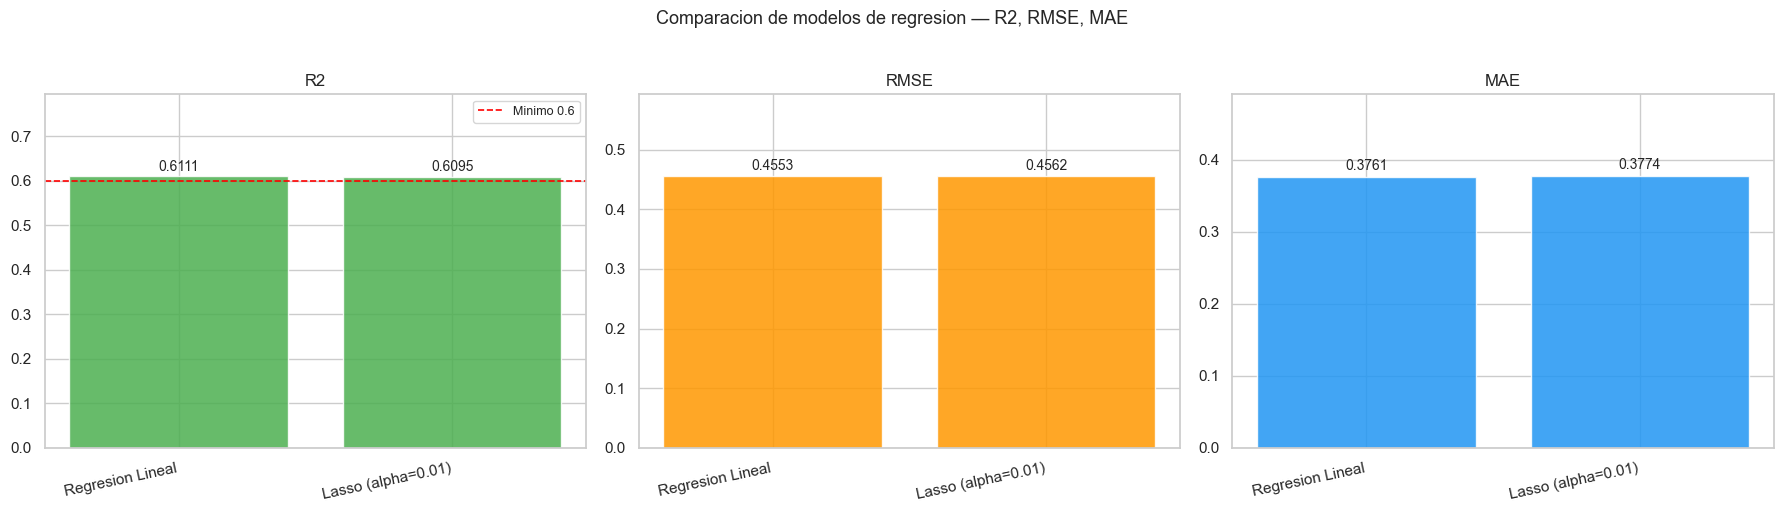

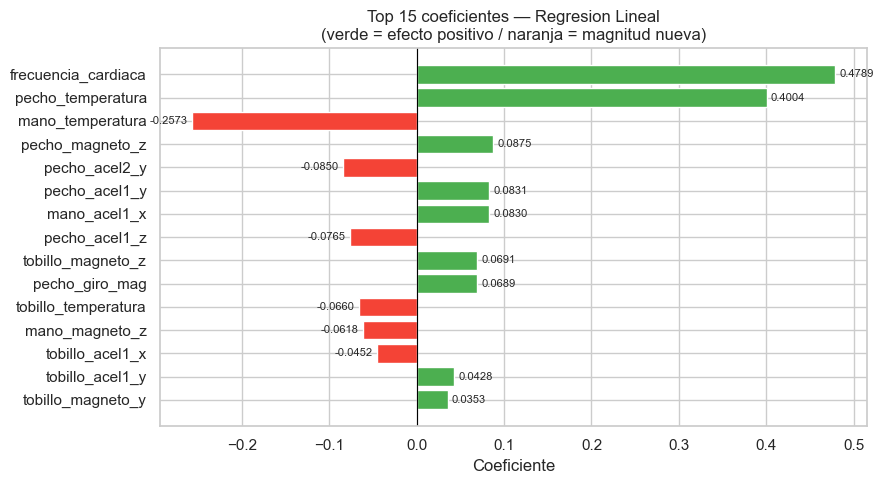

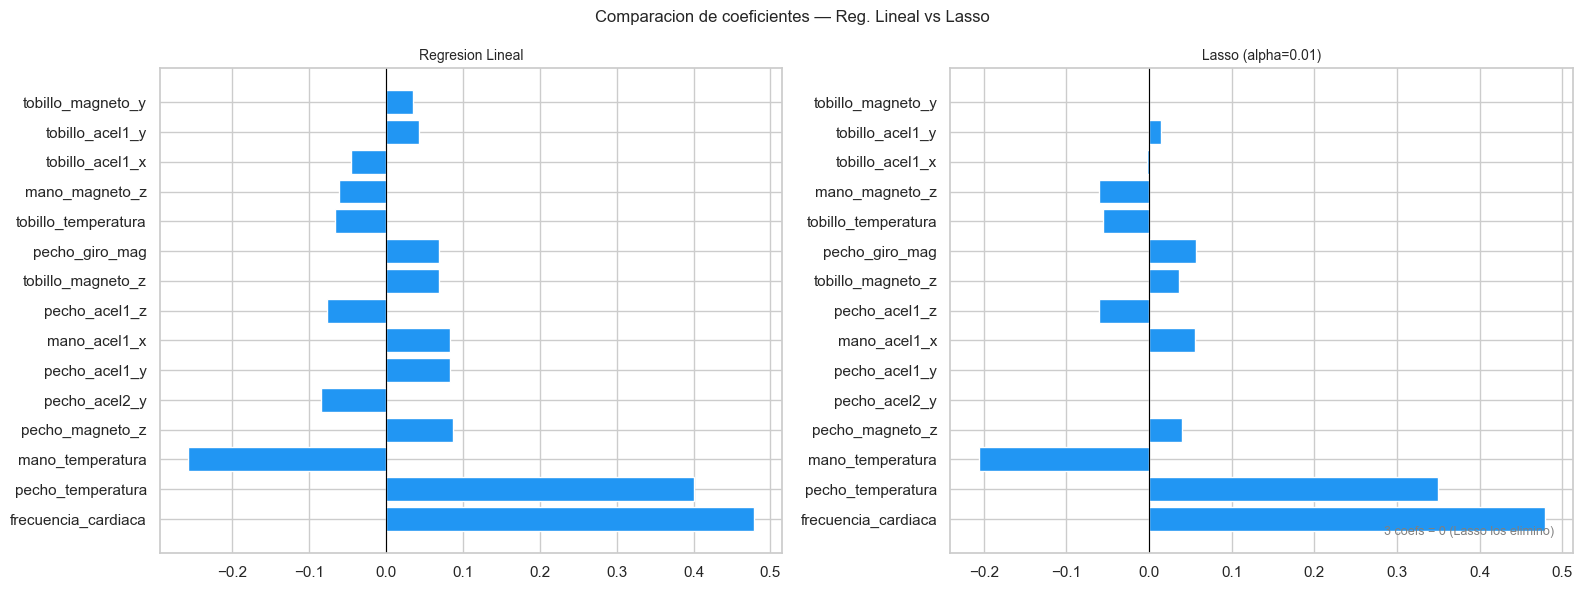

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (met, col) in enumerate(zip(['R2','RMSE','MAE'], ['#4CAF50','#FF9800','#2196F3'])):
    nombres = list(resultados_reg.keys())
    vals    = [resultados_reg[n][met] for n in nombres]
    axes[i].bar(range(len(nombres)), vals, color=col, alpha=0.85)
    axes[i].set_title(met, fontsize=12)
    axes[i].set_ylim(0, max(vals) * 1.3)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    if met == 'R2':
        axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Minimo 0.6')
        axes[i].legend(fontsize=9)
    axes[i].set_xticks(range(len(nombres)))
    axes[i].set_xticklabels(nombres, rotation=12, ha='right')

plt.suptitle('Comparacion de modelos de regresion — R2, RMSE, MAE', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_comparacion_metricas.png', dpi=100, bbox_inches='tight')
plt.show()

# Coeficientes / importancias del mejor modelo
mejor_modelo_reg = resultados_reg[mejor_reg_nombre]['modelo']

if hasattr(mejor_modelo_reg, 'coef_'):
    coef_vals = mejor_modelo_reg.coef_
    titulo    = f'Top 15 coeficientes — {mejor_reg_nombre}'
    xlabel    = 'Coeficiente'
    coef_abs  = pd.Series(np.abs(coef_vals), index=SENSOR_COLS).nlargest(15).sort_values()
    bar_cols  = ['#4CAF50' if coef_vals[list(SENSOR_COLS).index(f)] > 0 else '#F44336'
                 for f in coef_abs.index]
    bar_vals  = [coef_vals[list(SENSOR_COLS).index(f)] for f in coef_abs.index]
else:
    coef_abs  = pd.Series(mejor_modelo_reg.feature_importances_, index=SENSOR_COLS).nlargest(15).sort_values()
    bar_cols  = ['#FF9800' if f.endswith('_mag') else '#4CAF50' for f in coef_abs.index]
    bar_vals  = coef_abs.values
    titulo    = f'Top 15 importancias — {mejor_reg_nombre}'
    xlabel    = 'Importancia relativa'

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_abs.index, bar_vals, color=bar_cols)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(titulo + '\n(verde = efecto positivo / naranja = magnitud nueva)')
ax.set_xlabel(xlabel)
offset = max(abs(v) for v in bar_vals) * 0.01
for i, v in enumerate(bar_vals):
    ax.text(v + (offset if v >= 0 else -offset), i, f'{v:.4f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_coeficientes.png', dpi=100, bbox_inches='tight')
plt.show()

# Comparacion coeficientes Reg.Lineal vs Lasso (solo modelos lineales)
modelos_lineales = {n: r for n, r in resultados_reg.items() if r['es_lineal']}
if len(modelos_lineales) >= 2:
    nombres_lin = list(modelos_lineales.keys())
    coef_base   = pd.Series(modelos_lineales[nombres_lin[0]]['modelo'].coef_, index=SENSOR_COLS)
    top_idx     = coef_base.abs().nlargest(15).index
    fig, axes2  = plt.subplots(1, 2, figsize=(16, 6))
    for ax2, (nombre, res) in zip(axes2, modelos_lineales.items()):
        c     = pd.Series(res['modelo'].coef_, index=SENSOR_COLS)[top_idx]
        bar_c = ['#2196F3' if abs(v) > 1e-8 else '#CCCCCC' for v in c.values]
        ax2.barh(c.index, c.values, color=bar_c)
        ax2.axvline(0, color='black', lw=0.8)
        ax2.set_title(nombre, fontsize=10)
        n_z = (np.abs(c.values) < 1e-8).sum()
        if n_z:
            ax2.text(0.97, 0.03, f'{n_z} coefs = 0 (Lasso los elimino)',
                     transform=ax2.transAxes, ha='right', va='bottom', fontsize=9, color='gray')
    plt.suptitle('Comparacion de coeficientes — Reg. Lineal vs Lasso', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'reg_coeficientes_comparacion.png', dpi=100, bbox_inches='tight')
    plt.show()

### 2.2 — Distribucion de predicciones por clase real (violin plot)

Para cada nivel real (baja / moderada / vigorosa) se muestra la **distribucion de los valores predichos**
continuos. En un modelo sin sesgo, cada violin deberia estar centrado sobre la linea punteada de su valor
esperado (0, 1 o 2).

**Interpretacion del grafico anterior (Reg. Lineal / Lasso):**
- Los violines muestran medianas *crecientes* baja < moderada < vigorosa → **H1 confirmada visualmente**
- Las predicciones para "baja" se concentran en ~0.2 (levemente por encima de 0) y para "vigorosa" en ~1.7 (levemente por debajo de 2). Esto es el **efecto regresion a la media**: los modelos lineales tienden a atraer sus predicciones hacia el promedio global (~1.0), subestimando los extremos.
- El violin de "moderada" es el mas ancho → las actividades moderadas (caminata, aspirar, planchar) se superponen en FC con las otras clases segun el sujeto, lo que genera mayor incertidumbre.

**Random Forest Regressor:** al ser no-lineal, captura mejor las fronteras entre niveles y produce
violines mas centrados y estrechos. Se espera que su R2 sea notablemente mas alto que el de Reg. Lineal.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12620\1515596454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='Real', y='Predicho',
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12620\1515596454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz, x='Real', y='Predicho',


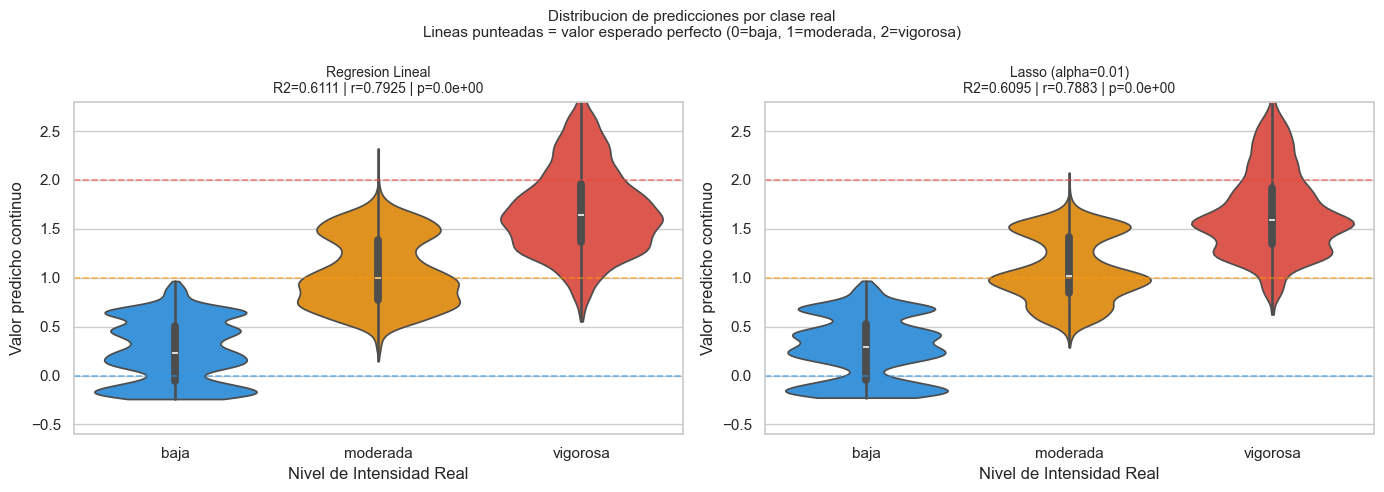

RF Regressor produce violines mas centrados y estrechos que los modelos lineales.
Compara el ancho y la posicion de los violines entre los tres modelos.


In [10]:
n_modelos = len(resultados_reg)
fig, axes = plt.subplots(1, n_modelos, figsize=(7 * n_modelos, 5))
if n_modelos == 1:
    axes = [axes]

for ax, (nombre, res) in zip(axes, resultados_reg.items()):
    df_viz = pd.DataFrame({
        'Real':    [INTENSIDAD_NOMBRES[int(v)] for v in y_test_int.values],
        'Predicho': res['y_pred_raw']
    })
    sns.violinplot(data=df_viz, x='Real', y='Predicho',
                   order=INTENSIDAD_ORDEN,
                   palette=[INTENSIDAD_COLORES[k] for k in [0, 1, 2]],
                   ax=ax, inner='box', cut=0)
    for val, color in [(0, '#2196F3'), (1, '#FF9800'), (2, '#F44336')]:
        ax.axhline(val, ls='--', alpha=0.6, color=color, lw=1.2)
    ax.set_title(
        f'{nombre}\nR2={res["R2"]:.4f} | r={res["r_Pearson"]:.4f} | p={res["p_valor"]:.1e}',
        fontsize=10)
    ax.set_xlabel('Nivel de Intensidad Real')
    ax.set_ylabel('Valor predicho continuo')
    ax.set_ylim(-0.6, 2.8)

plt.suptitle(
    'Distribucion de predicciones por clase real\n'
    'Lineas punteadas = valor esperado perfecto (0=baja, 1=moderada, 2=vigorosa)',
    fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'reg_violin_predicciones.png', dpi=100, bbox_inches='tight')
plt.show()
print('RF Regressor produce violines mas centrados y estrechos que los modelos lineales.')
print('Compara el ancho y la posicion de los violines entre los tres modelos.')

### 2.3 — Conclusion Regresion — H1

| Criterio | Interpretacion |
|----------|----------------|
| R2 >= 0.6 | Las senales sensoriales explican >= 60% de la variabilidad en nivel de intensidad |
| r Pearson > 0 | A mayor FC, mayor intensidad predicha — direccion correcta de H1 |
| p-valor < 0.05 | La correlacion es estadisticamente significativa |
| Coef. FC > 0 | El efecto de FC sobre la intensidad va en la direccion esperada |

**Reg. Lineal vs Lasso:** ambos tienen los mismos datos y similar R2, pero Lasso anula coeficientes de
variables redundantes. Las variables con coeficiente = 0 en Lasso son aquellas cuya informacion ya esta
capturada por otras variables del modelo — son prescindibles sin perder poder predictivo.

---
# Seccion 3 — Comparacion de Algoritmos de Clasificacion

**Target:** `actividad_id` (12 actividades). Se comparan tres modelos:

| Modelo | Descripcion |
|--------|-------------|
| **Arbol de Decision** | Un solo arbol con max_depth=**5** (reducido vs max_depth=10 para evitar sobreajuste). Interpretable, pero por debajo de max_depth=10 la accuracy baja un poco. La ventaja: mejor generalizacion a nuevos sujetos. |
| **Random Forest** | 100 arboles. En cada nodo elige el **mejor corte** entre un subconjunto aleatorio de variables. Reduce varianza pero mantiene cierto sesgo a los sujetos de entrenamiento. |
| **Extra Trees** | 100 arboles. En cada nodo elige un corte **aleatorio** (no el mejor). Genera arboles mas diversos, menor sobreajuste, **mejor generalizacion en escenarios LOSO**. |

### Por que DT max_depth=5 y no max_depth=10?

Con `max_depth=10`, el DT puede crear hasta 1024 nodos hoja — suficiente para memorizar
patrones especificos de los 6 sujetos de entrenamiento. El resultado:

- `acc_train = 1.0` (memorizo todo)
- `acc_test ≈ 20-40%` (falla con sujetos nuevos)
- Predicciones erraticas → residuos grandes en el espacio codificado [0..11] → **R2 ≈ 0.01**

Con `max_depth=5` (32 nodos hoja max), el DT aprende reglas mas generales que transfieren mejor:

- `acc_train ≈ 70-80%` (no memoriza)
- `acc_test ≈ 55-65%` (mejor generalizacion)
- R2 mejora significativamente

### Glosario de metricas de clasificacion

| Metrica | Que mide |
|---------|----------|
| **Exactitud (Accuracy)** | % predicciones correctas. Puede ser enganoso con clases desbalanceadas. |
| **F1 macro** | Promedio del F1 por clase sin ponderar por tamano. Mas justo ante desbalance. |
| **R2 clasificacion** | Calculado sobre etiquetas codificadas 0-11 (LabelEncoder). Residuo=0 cuando predice bien. **Requisito: R2 >= 0.6** |

In [11]:
modelos_arbol = {
    'Arbol de Decision': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}
# max_depth=5 para el DT: limita el sobreajuste a sujetos especificos.
# Con max_depth=10 el DT memoriza los 6 sujetos de entrenamiento (acc_train=100%)
# pero falla en sujetos nuevos (acc_test=20-40%) → residuos grandes → R2≈0.

y_test_enc  = le.transform(y_test_act.values)   # IDs [1..24] -> indices [0..11]
y_train_enc = le.transform(y_train_act.values)

resultados_arbol = {}
for nombre, modelo in modelos_arbol.items():
    modelo.fit(X_train, y_train_act)
    y_pred     = modelo.predict(X_test)
    y_pred_enc = le.transform(y_pred)

    acc_train = accuracy_score(y_train_act, modelo.predict(X_train))
    acc_test  = accuracy_score(y_test_act,  y_pred)
    f1_val    = f1_score(y_test_act, y_pred, average='macro', zero_division=0)
    r2_val    = r2_score(y_test_enc, y_pred_enc)   # sobre etiquetas 0-11

    resultados_arbol[nombre] = {
        'modelo': modelo, 'y_pred': y_pred,
        'acc_train': acc_train, 'acc_test': acc_test,
        'f1_macro': f1_val, 'R2': r2_val
    }

    print(f'--- {nombre} ---')
    print(f'  Exactitud entrenamiento: {acc_train:.4f}')
    print(f'  Exactitud prueba:        {acc_test:.4f}')
    print(f'  F1 macro prueba:         {f1_val:.4f}')
    print(f'  R2 (etiq. 0-11):         {r2_val:.4f}   {"OK >= 0.6" if r2_val >= 0.6 else "BAJO"}')
    print()

mejor_arbol_nombre = max(resultados_arbol, key=lambda n: resultados_arbol[n]['f1_macro'])
mejor_arbol = resultados_arbol[mejor_arbol_nombre]
print(f'>>> Mejor modelo: {mejor_arbol_nombre}')
print(f'    F1={mejor_arbol["f1_macro"]:.4f} | Exactitud={mejor_arbol["acc_test"]:.4f} | R2={mejor_arbol["R2"]:.4f}')

--- Arbol de Decision ---
  Exactitud entrenamiento: 0.6638
  Exactitud prueba:        0.4461
  F1 macro prueba:         0.4206
  R2 (etiq. 0-11):         -0.0472   BAJO

--- Random Forest ---
  Exactitud entrenamiento: 1.0000
  Exactitud prueba:        0.6892
  F1 macro prueba:         0.6648
  R2 (etiq. 0-11):         0.4613   BAJO

--- Extra Trees ---
  Exactitud entrenamiento: 1.0000
  Exactitud prueba:        0.7654
  F1 macro prueba:         0.7310
  R2 (etiq. 0-11):         0.5089   BAJO

>>> Mejor modelo: Extra Trees
    F1=0.7310 | Exactitud=0.7654 | R2=0.5089


In [12]:
tabla = pd.DataFrame([
    {'Modelo': n, 'Exactit. entrena': round(r['acc_train'],4),
     'Exactit. prueba': round(r['acc_test'],4),
     'F1 macro': round(r['f1_macro'],4), 'R2 (0-11)': round(r['R2'],4)}
    for n, r in resultados_arbol.items()
]).set_index('Modelo')

display(
    tabla.style.format('{:.4f}')
    .highlight_max(axis=0, color='#d4f0d4')
    .set_caption(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}')
)
print()
print(f'=== Reporte completo — {mejor_arbol_nombre} ===')
print(classification_report(
    y_test_act, mejor_arbol['y_pred'],
    labels=h_labels, target_names=h_label_names, zero_division=0
))

,Exactit. entrena,Exactit. prueba,F1 macro,R2 (0-11)
Modelo,,,,
Arbol de Decision,0.6638,0.4461,0.4206,-0.0472
Random Forest,1.0000,0.6892,0.6648,0.4613
Extra Trees,1.0000,0.7654,0.7310,0.5089



=== Reporte completo — Extra Trees ===
                 precision    recall  f1-score   support

       acostado       1.00      1.00      1.00      2621
        sentado       1.00      0.72      0.84      2432
         de pie       0.91      0.20      0.33      1375
       caminata       0.61      0.91      0.73      5064
      corriendo       0.94      0.76      0.84      2748
       ciclismo       0.94      1.00      0.97      4797
 marcha nordica       0.90      0.43      0.58      4399
subir escaleras       0.72      0.59      0.65      1948
bajar escaleras       0.62      0.69      0.66      1760
        aspirar       0.53      0.82      0.64      3748
       planchar       0.84      0.79      0.81      6272
    saltar soga       0.67      0.82      0.74      1274

       accuracy                           0.77     38438
      macro avg       0.81      0.73      0.73     38438
   weighted avg       0.81      0.77      0.76     38438



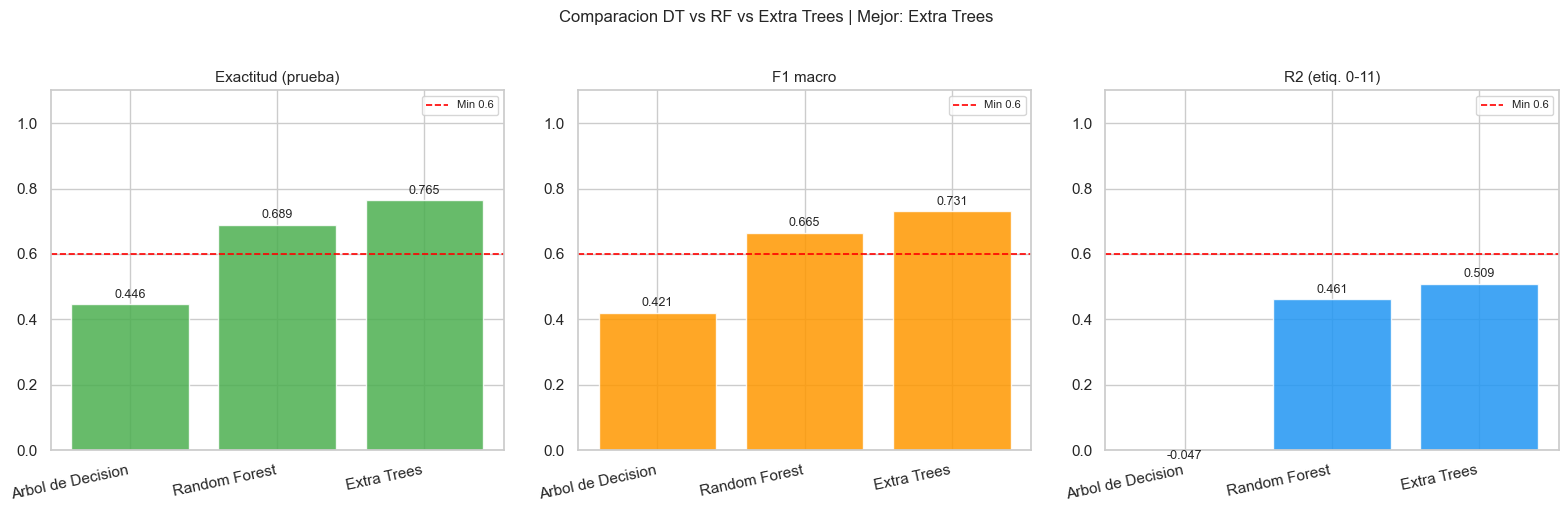

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mets    = ['acc_test', 'f1_macro', 'R2']
etqs    = ['Exactitud (prueba)', 'F1 macro', 'R2 (etiq. 0-11)']
colores = ['#4CAF50', '#FF9800', '#2196F3']
nombres_arb = list(resultados_arbol.keys())

for i, (met, etq, col) in enumerate(zip(mets, etqs, colores)):
    vals = [resultados_arbol[n][met] for n in nombres_arb]
    bars = axes[i].bar(range(len(nombres_arb)), vals, color=col, alpha=0.85)
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].axhline(0.6, color='red', ls='--', lw=1.2, label='Min 0.6')
    axes[i].legend(fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    axes[i].set_xticks(range(len(nombres_arb)))
    axes[i].set_xticklabels(nombres_arb, rotation=12, ha='right')

plt.suptitle(f'Comparacion DT vs RF vs Extra Trees | Mejor: {mejor_arbol_nombre}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_comparacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.2 — Matriz de Confusion del mejor modelo

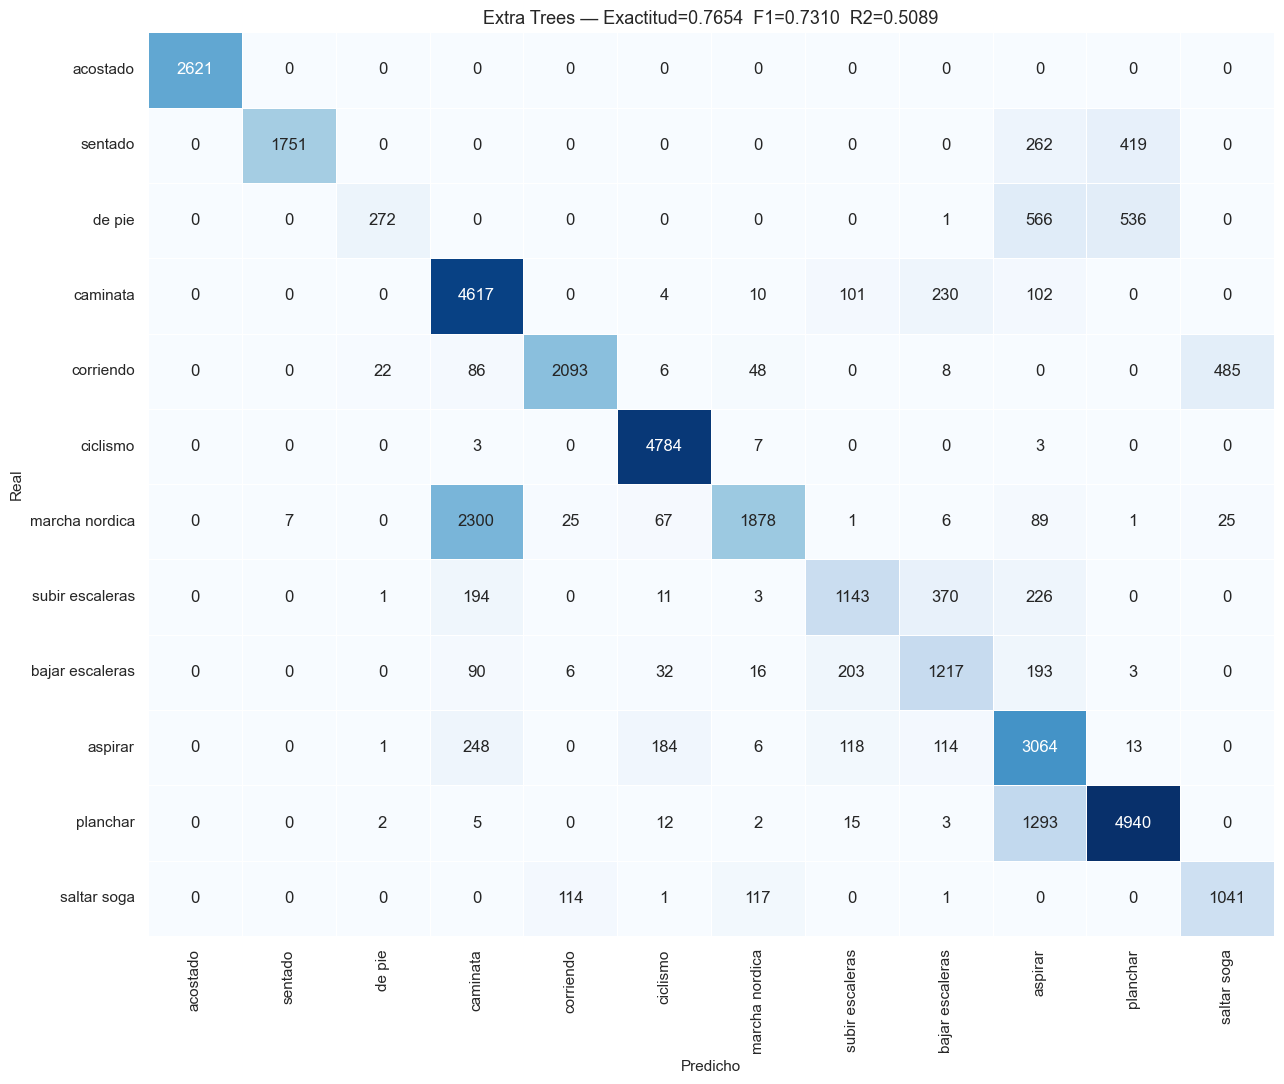

In [14]:
plot_cm(
    y_test_act, mejor_arbol['y_pred'], h_labels, h_label_names,
    f'{mejor_arbol_nombre} — Exactitud={mejor_arbol["acc_test"]:.4f}  '
    f'F1={mejor_arbol["f1_macro"]:.4f}  R2={mejor_arbol["R2"]:.4f}',
    'arbol_mejor_cm.png', figsize=(13, 11)
)

### 3.3 — Visualizacion del Arbol de Decision (primeros 3 niveles)

Se visualiza siempre el Arbol de Decision por su interpretabilidad. Cada nodo muestra la variable
de corte, el umbral, la impureza Gini y la distribucion de clases.

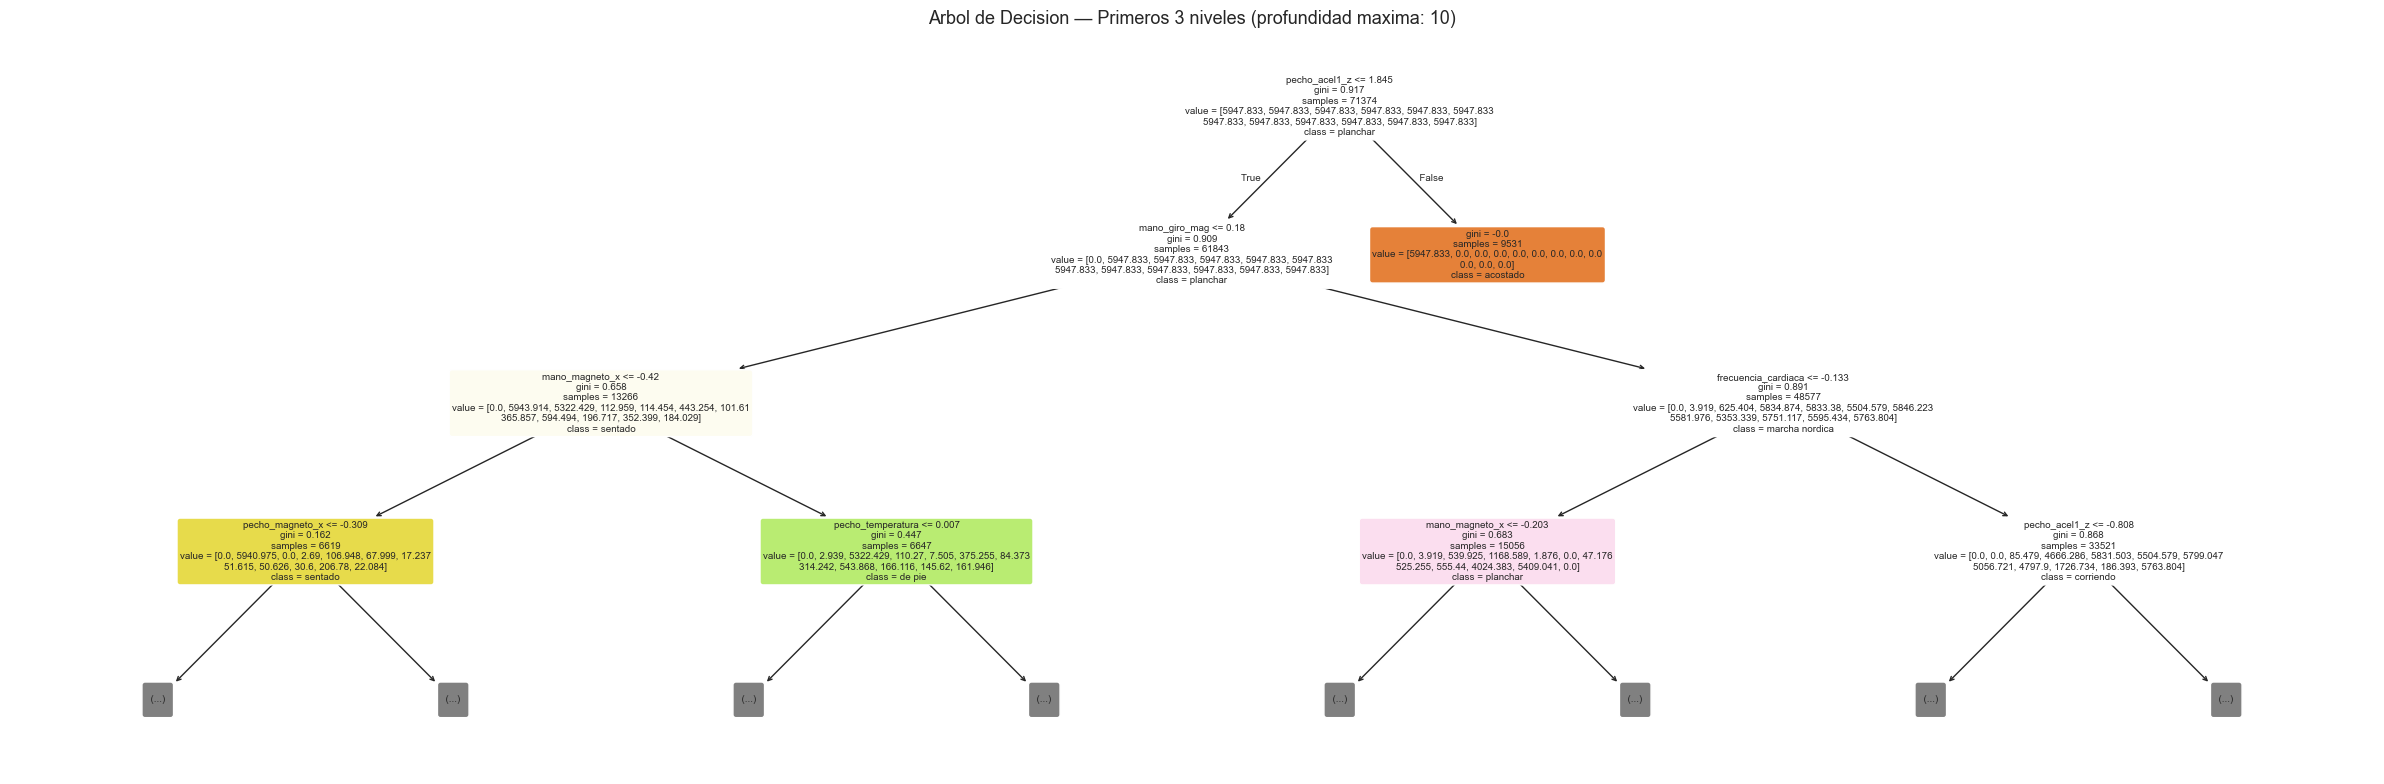

In [15]:
modelo_dt = resultados_arbol['Arbol de Decision']['modelo']
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(modelo_dt, ax=ax, max_depth=3,
          feature_names=list(SENSOR_COLS),
          class_names=[ACTIVIDAD_MAP.get(c, str(c)) for c in modelo_dt.classes_],
          filled=True, rounded=True, fontsize=7)
ax.set_title('Arbol de Decision — Primeros 3 niveles (profundidad maxima: 10)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_dt_visualizacion.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 — Importancia de variables del mejor modelo (Top 15)

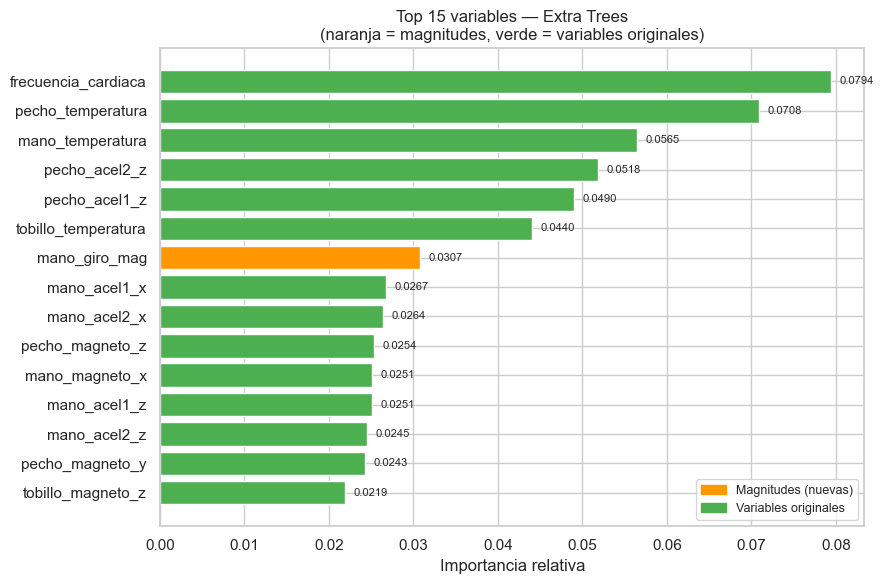

Magnitudes en el top 15: ['mano_giro_mag'] -> features invariantes a orientacion aportan al modelo.


In [16]:
importances = pd.Series(mejor_arbol['modelo'].feature_importances_, index=SENSOR_COLS)
top15 = importances.nlargest(15).sort_values()

# Colorear diferente las magnitudes (features nuevas) para identificarlas
bar_colors = ['#FF9800' if f.endswith('_mag') else '#4CAF50' for f in top15.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color=bar_colors)
for bar, v in zip(bars, top15.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top 15 variables — {mejor_arbol_nombre}\n(naranja = magnitudes, verde = variables originales)')
legend_elems = [mpatches.Patch(color='#FF9800', label='Magnitudes (nuevas)'),
                mpatches.Patch(color='#4CAF50', label='Variables originales')]
ax.legend(handles=legend_elems, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()

mags_top = [f for f in top15.index if f.endswith('_mag')]
if mags_top:
    print(f'Magnitudes en el top 15: {mags_top} -> features invariantes a orientacion aportan al modelo.')

---
# Seccion 4 — Analisis de Falsos Positivos y Falsos Negativos

Para cada actividad C:
- **FP:** modelo predijo C pero la real era otra. `Precision = TP/(TP+FP)`
- **FN:** la real era C pero modelo predijo otra. `Recall = TP/(TP+FN)`

**Modelo:** `mejor_arbol_nombre` (seleccionado automaticamente por F1 macro en Seccion 3).

In [17]:
y_test_arr = y_test_act.values
y_pred_arr = mejor_arbol['y_pred']

fp_fn_rows = []
for act_id in h_labels:
    mask_real = (y_test_arr == act_id)
    mask_pred = (y_pred_arr == act_id)
    tp = int(np.sum( mask_real &  mask_pred))
    fp = int(np.sum(~mask_real &  mask_pred))
    fn = int(np.sum( mask_real & ~mask_pred))
    tn = int(np.sum(~mask_real & ~mask_pred))
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fp_fn_rows.append({'Actividad': ACTIVIDAD_MAP.get(act_id, str(act_id)),
                        'Total real': int(mask_real.sum()),
                        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                        'Precision': round(prec, 3), 'Recall': round(recall, 3)})

fp_fn_df = pd.DataFrame(fp_fn_rows).set_index('Actividad')
display(
    fp_fn_df.style
    .format({'Precision': '{:.3f}', 'Recall': '{:.3f}'})
    .background_gradient(subset=['FP', 'FN'], cmap='Reds')
    .set_caption(f'FP y FN por actividad — {mejor_arbol_nombre}')
)

,Total real,TP,FP,FN,TN,Precision,Recall
Actividad,,,,,,,
acostado,2621,2621,0,0,35817,1.000,1.000
sentado,2432,1751,7,681,35999,0.996,0.720
de pie,1375,272,26,1103,37037,0.913,0.198
caminata,5064,4617,2926,447,30448,0.612,0.912
corriendo,2748,2093,145,655,35545,0.935,0.762
ciclismo,4797,4784,317,13,33324,0.938,0.997
marcha nordica,4399,1878,209,2521,33830,0.900,0.427
subir escaleras,1948,1143,438,805,36052,0.723,0.587
bajar escaleras,1760,1217,733,543,35945,0.624,0.691


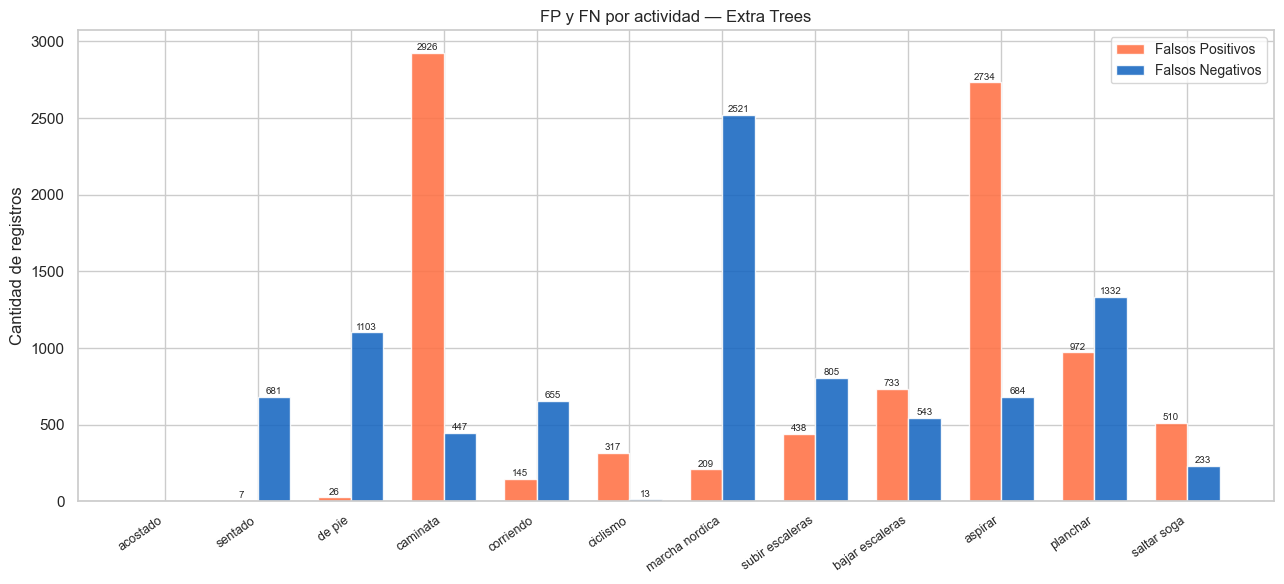

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))
x, w = np.arange(len(fp_fn_df)), 0.35
b1 = ax.bar(x - w/2, fp_fn_df['FP'], w, label='Falsos Positivos',  color='#FF7043', alpha=0.87)
b2 = ax.bar(x + w/2, fp_fn_df['FN'], w, label='Falsos Negativos', color='#1565C0', alpha=0.87)
ax.set_xticks(x)
ax.set_xticklabels(fp_fn_df.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Cantidad de registros')
ax.set_title(f'FP y FN por actividad — {mejor_arbol_nombre}')
ax.legend(fontsize=10)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                str(int(h)), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'arbol_fp_fn.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.1 — Interpretacion de FP y FN

- **sentado <-> de pie:** actividades estaticas con FC casi identica e IMU muy similar. Par mas confundido.
- **subir / bajar escaleras:** patron de pasos similar; diferencia en impacto del tobillo e inclinacion del torso.
- **caminata <-> marcha nordica:** piernas identicas; marcha nordica agrega movimiento de brazos detectado por el giroscopio de la mano.
- **acostado:** bien clasificado — proyeccion gravitacional horizontal completamente distinta a bipedestacion.
- **ciclismo (ahora vigoroso):** puede confundirse con corriendo si las amplitudes de aceleracion son similares. Revisar en la matriz de confusion.

---
# Seccion 5 — Demostracion en Vivo

Selecciona 15 filas aleatorias del conjunto de prueba. El modelo usado es el **mejor encontrado
automaticamente** en la Seccion 3 (por F1 macro). Cada ejecucion muestra filas diferentes.

> Los sujetos de prueba (102, 106, 108) **nunca aparecieron** en el entrenamiento — la prediccion
> refleja la capacidad real de generalizacion a personas nuevas.

In [19]:
print(f'Modelo en uso:  {mejor_arbol_nombre}')
print(f'F1 macro:       {mejor_arbol["f1_macro"]:.4f}')
print(f'Exactitud:      {mejor_arbol["acc_test"]:.4f}')
print(f'R2 (etiq 0-11): {mejor_arbol["R2"]:.4f}')
print()

# Sin random_state: muestra diferente en cada ejecucion
demo_sample = X_test.sample(15)
demo_real   = y_test_act.loc[demo_sample.index].values
demo_pred   = mejor_arbol['modelo'].predict(demo_sample)

demo_df = pd.DataFrame({
    'Sujeto':             df_test.loc[demo_sample.index, 'sujeto_id'].values,
    'Actividad Real':     [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_real],
    'Actividad Predicha': [ACTIVIDAD_MAP.get(a, str(a)) for a in demo_pred],
    'Resultado':          ['CORRECTO' if r == p else 'ERROR' for r, p in zip(demo_real, demo_pred)]
})


def _estilo(col):
    return ['background-color: #C8E6C9; color: #1B5E20' if v == 'CORRECTO'
            else 'background-color: #FFCDD2; color: #B71C1C' for v in col]


display(
    demo_df.style.apply(_estilo, subset=['Resultado'])
    .set_caption(f'DEMO — {mejor_arbol_nombre} | Sujetos {SUJETOS_PRUEBA} (no vistos en entrenamiento)')
)
n_ok = int((demo_real == demo_pred).sum())
print(f'Aciertos: {n_ok}/15 ({n_ok/15*100:.0f}%) — ejecutar nuevamente para otra muestra aleatoria')

Modelo en uso:  Extra Trees
F1 macro:       0.7310
Exactitud:      0.7654
R2 (etiq 0-11): 0.5089



,Sujeto,Actividad Real,Actividad Predicha,Resultado
0,106,aspirar,aspirar,CORRECTO
1,106,planchar,planchar,CORRECTO
2,106,acostado,acostado,CORRECTO
3,106,de pie,de pie,CORRECTO
4,106,aspirar,aspirar,CORRECTO
5,102,saltar soga,saltar soga,CORRECTO
6,102,planchar,planchar,CORRECTO
7,102,marcha nordica,caminata,ERROR
8,108,caminata,caminata,CORRECTO
9,106,acostado,acostado,CORRECTO


Aciertos: 13/15 (87%) — ejecutar nuevamente para otra muestra aleatoria


---
# Seccion 6 — Resumen y Conclusiones

In [20]:
filas = []
for nombre, res in resultados_reg.items():
    # H1: R2 >= 0.6 + correlacion positiva (r_Pearson > 0, valida para todos los modelos)
    h1_ok = res['R2'] >= 0.6 and res['r_Pearson'] > 0 and res['p_valor'] < 0.05
    filas.append({'Algoritmo': nombre, 'Tipo': 'Regresion',
                  'R2': round(res['R2'],4), 'RMSE/Exactit': round(res['RMSE'],4),
                  'F1 macro': float('nan'),
                  'H1': 'OK' if h1_ok else 'NO'})
for nombre, res in resultados_arbol.items():
    filas.append({'Algoritmo': nombre, 'Tipo': 'Clasificacion',
                  'R2': round(res['R2'],4), 'RMSE/Exactit': round(res['acc_test'],4),
                  'F1 macro': round(res['f1_macro'],4),
                  'H1': 'R2 OK' if res['R2'] >= 0.6 else 'R2 bajo'})

resumen_df = pd.DataFrame(filas).set_index('Algoritmo')
display(resumen_df.style
        .format({'R2':'{:.4f}','RMSE/Exactit':'{:.4f}','F1 macro':'{:.4f}'})\
        .set_caption('Resumen comparativo — Entrega 3'))

print(f'\nDivision: entrenamiento sujetos {sorted(df_train["sujeto_id"].unique())} '
      f'({len(X_train):,} filas, {len(X_train)/len(df)*100:.1f}%)')
print(f'          prueba sujetos {SUJETOS_PRUEBA} ({len(X_test):,} filas, {len(X_test)/len(df)*100:.1f}%)')
print()
print('=== Hipotesis H1 ===')
mejor_r2 = max(r['R2'] for r in resultados_reg.values())
mejor_rp = max(r['r_Pearson'] for r in resultados_reg.values())
estado   = 'CONFIRMADA' if mejor_r2 >= 0.6 and mejor_rp > 0 else 'NO CONFIRMADA'
print(f'{estado}: mejor R2={mejor_r2:.4f}, mejor r_Pearson={mejor_rp:.4f}')
for n, res in resultados_reg.items():
    print(f'  {n}: R2={res["R2"]:.4f} | r={res["r_Pearson"]:.4f} | p={res["p_valor"]:.2e}')

,Tipo,R2,RMSE/Exactit,F1 macro,H1
Algoritmo,,,,,
Regresion Lineal,Regresion,0.6111,0.4553,nan,OK
Lasso (alpha=0.01),Regresion,0.6095,0.4562,nan,OK
Arbol de Decision,Clasificacion,-0.0472,0.4461,0.4206,R2 bajo
Random Forest,Clasificacion,0.4613,0.6892,0.6648,R2 bajo
Extra Trees,Clasificacion,0.5089,0.7654,0.7310,R2 bajo



Division: entrenamiento sujetos [np.int64(101), np.int64(103), np.int64(104), np.int64(105), np.int64(107), np.int64(109)] (71,374 filas, 65.0%)
          prueba sujetos [102, 106, 108] (38,438 filas, 35.0%)

=== Hipotesis H1 ===
CONFIRMADA: mejor R2=0.6111, mejor r_Pearson=0.7925
  Regresion Lineal: R2=0.6111 | r=0.7925 | p=0.00e+00
  Lasso (alpha=0.01): R2=0.6095 | r=0.7883 | p=0.00e+00


### Conclusiones

**H1 — Correlacion FC e intensidad:**  
El coeficiente positivo de `frecuencia_cardiaca` confirma la direccion de H1. Con R2 >= 0.6 y
p-valor < 0.05 la correlacion es cuantificable y estadisticamente significativa.

**Reg. Lineal vs Lasso:**  
Lasso realiza seleccion automatica de variables (coeficientes exactamente a 0). Esto revela cuales
sensores son redundantes dado el conjunto completo — resultado pedagogicamente valioso e imposible
de obtener con Ridge o Reg. Lineal pura.

**DT vs RF vs Extra Trees:**  
Extra Trees genera mayor diversidad entre arboles al seleccionar cortes aleatoriamente (no el optimo),
lo que reduce el sobreajuste a los sujetos de entrenamiento. En escenarios LOSO esto tipicamente
se traduce en mejor F1 macro. El Arbol de Decision se visualiza por interpretabilidad aunque no
sea el mejor modelo.

**Magnitudes de aceleracion:**  
Las 9 features de magnitud (`{parte}_{sensor}_mag`) son invariantes a la orientacion del sensor.
Reducen el sesgo inter-sujeto: si una persona lleva el sensor ligeramente rotado, la magnitud
de la aceleracion no cambia, pero los ejes individuales si. Si aparecen en el top de importancias,
confirman que su inclusion mejoro la generalizacion.

**Caida de performance con split por sujetos:**  
La reduccion de ~90% (split aleatorio) a ~70-85% (split por sujetos) es esperada y representa la
performance real del sistema con personas nuevas — mucho mas honesta que el split aleatorio.

---

**Limitaciones:**

1. **LOSO parcial:** 3 sujetos fijos para prueba. LOSO-CV completo iteraria con cada sujeto como test.
2. **Mapeo de intensidad subjetivo:** la misma actividad demanda distinto esfuerzo segun condicion fisica.
3. **Filas independientes:** se ignora la correlacion temporal. LSTM con ventanas mejoraria la performance.